# Test metric Eggert

Tempo di calcolo: 0.76 s
Simmetria utilizzata: True
Stati calcolati: 13,275 / 26,325
P_H: [0.0000, 1.0000]
V0:  [-0.2000, 0.8000]


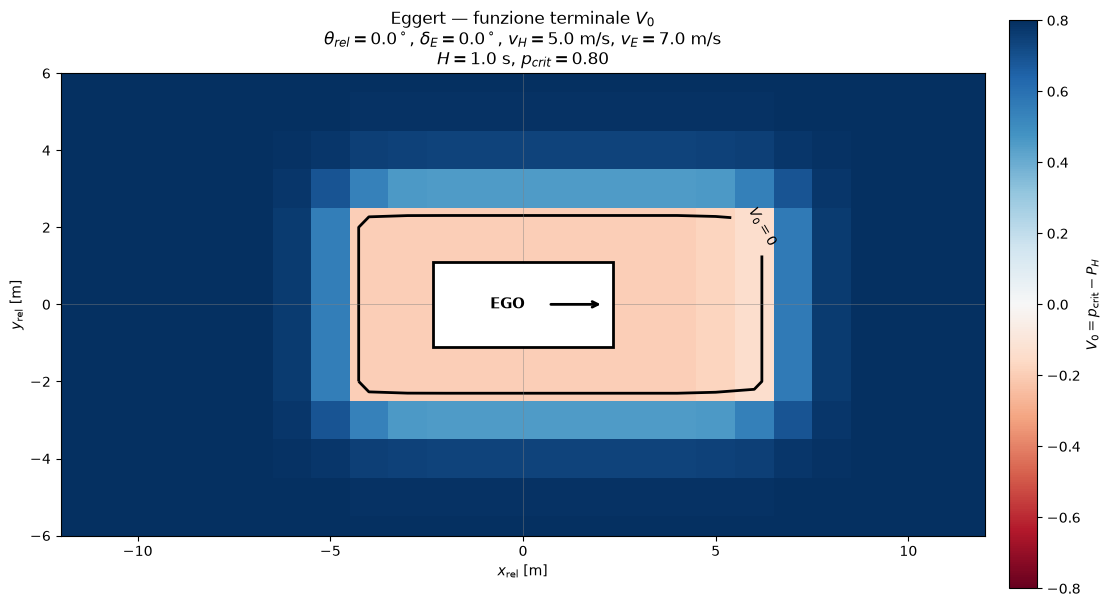

In [13]:
from pathlib import Path
from time import perf_counter
import sys
import importlib

import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# ============================================================
# 1. IMPORT
# ============================================================

ROOT = next(
    (
        directory
        for directory in (Path.cwd(), *Path.cwd().parents)
        if (directory / "hj_reachability").is_dir()
        and (directory / "scripts").is_dir()
    ),
    None,
)

if ROOT is None:
    raise RuntimeError("Esegui il notebook all'interno del progetto.")

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import hj_reachability as hj
from hj_reachability.systems.relative_vehicle_6d import RelativeVehicle6D
from hj_reachability.vehicle.geometry.rectangles import DEFAULT_EGO_GEOMETRY
import hj_reachability.vehicle.metrics.eggert as eggert

importlib.reload(eggert)

# ============================================================
# 2. PARAMETRI DELLA METRICA
# ============================================================

METRIC_PARAMETERS = {
    "horizon": 1.0,
    "dt": 0.05,
    "beta_d": 2.0,
    "tau_d0": 0.3,
    "escape_rate": 0.1,
    "p_crit": 0.8,
    "collision_tolerance": 1e-9,
    "contact_time_tolerance": 1e-5,
    "batch_size": 10_000,
    "use_symmetry": True,
}

dynamics = RelativeVehicle6D(lf=1.2, lr=1.5)

# ============================================================
# 3. GRIGLIA RIDOTTA
#
#    Ordine: [x_rel, y_rel, theta_rel, v_H, delta_E, v_E]
#    26 325 stati.
#
#    Theta non periodico: piccola finestra per il test di V0,
#    non una griglia destinata alla propagazione del BRT.
# ============================================================

grid = hj.Grid.from_lattice_parameters_and_boundary_conditions(
    domain=hj.sets.Box(
        lo=jnp.array([
            -12.0,
            -6.0,
            -np.deg2rad(10.0),
            4.0,
            -np.deg2rad(5.0),
            6.0,
        ]),
        hi=jnp.array([
            12.0,
            6.0,
            np.deg2rad(10.0),
            6.0,
            np.deg2rad(5.0),
            8.0,
        ]),
    ),
    shape=(25, 13, 3, 3, 3, 3),
    periodic_dims=(),
)

axes = tuple(np.asarray(axis) for axis in grid.coordinate_vectors)
x_axis, y_axis, theta_axis, vh_axis, delta_axis, ve_axis = axes

for name, axis in [
    ("x_rel", x_axis),
    ("y_rel", y_axis),
    ("theta_rel", theta_axis),
    ("delta_E", delta_axis),
]:
    assert np.any(axis == 0.0), f"Zero assente nell'asse {name}"

# ============================================================
# 4. CALCOLO DELLA NUOVA EGGERT
# ============================================================

start = perf_counter()

result = eggert.metricEggert(
    grid=grid,
    dynamics=dynamics,
    **METRIC_PARAMETERS,
)

elapsed = perf_counter() - start

P_H = result.probability
V0 = result.terminal_values

assert np.all(np.isfinite(P_H)), "Probabilità non finite."
assert np.all((P_H >= 0.0) & (P_H <= 1.0)), "Probabilità fuori da [0, 1]."

print(f"Tempo di calcolo: {elapsed:.2f} s")
print(f"Simmetria utilizzata: {result.parameters['symmetry_used']}")
print(
    f"Stati calcolati: {result.parameters['evaluated_states']:,}"
    f" / {result.parameters['total_states']:,}"
)
print(f"P_H: [{P_H.min():.4f}, {P_H.max():.4f}]")
print(f"V0:  [{V0.min():.4f}, {V0.max():.4f}]")

# ============================================================
# 5. FETTA DA VISUALIZZARE
#    Theta = 0 esatto; altri valori sul nodo più vicino.
# ============================================================

V_H_SLICE = 5.0
V_E_SLICE = 7.0
DELTA_E_SLICE_DEG = 0.0

i_theta = int(np.flatnonzero(theta_axis == 0.0)[0])
i_vh = int(np.argmin(np.abs(vh_axis - V_H_SLICE)))
i_ve = int(np.argmin(np.abs(ve_axis - V_E_SLICE)))
i_delta = int(np.argmin(
    np.abs(delta_axis - np.deg2rad(DELTA_E_SLICE_DEG))
))

V0_xy = V0[:, :, i_theta, i_vh, i_delta, i_ve]
X, Y = np.meshgrid(x_axis, y_axis, indexing="ij")

# ============================================================
# 6. PLOT: CAMPO V0, CONTORNO ZERO E RETTANGOLO EGO
# ============================================================

fig, ax = plt.subplots(figsize=(11, 6), constrained_layout=True)

p_crit = METRIC_PARAMETERS["p_crit"]
color_limit = max(p_crit, 1.0 - p_crit)

field = ax.pcolormesh(
    X,
    Y,
    V0_xy,
    shading="nearest",
    cmap="RdBu",
    vmin=-color_limit,
    vmax=color_limit,
    rasterized=True,
)

colorbar = fig.colorbar(field, ax=ax, pad=0.025)
colorbar.set_label(r"$V_0 = p_{\mathrm{crit}} - P_H$")

if V0_xy.min() < 0.0 < V0_xy.max():
    contour = ax.contour(
        X,
        Y,
        V0_xy,
        levels=[0.0],
        colors="black",
        linewidths=2.0,
    )
    ax.clabel(contour, fmt={0.0: r"$V_0=0$"}, fontsize=10)
else:
    print("La fetta selezionata non presenta un cambio di segno di V0.")

ego = DEFAULT_EGO_GEOMETRY

ax.add_patch(Rectangle(
    (-ego.half_length, -ego.half_width),
    ego.length,
    ego.width,
    facecolor="white",
    edgecolor="black",
    linewidth=2,
    zorder=5,
))

ax.text(
    -0.4, 0.0, "EGO",
    ha="center",
    va="center",
    fontsize=11,
    weight="bold",
    zorder=6,
)

ax.annotate(
    "",
    xy=(ego.half_length - 0.25, 0.0),
    xytext=(0.65, 0.0),
    arrowprops={"arrowstyle": "->", "color": "black", "lw": 2},
    zorder=6,
)

ax.axhline(0.0, color="gray", linewidth=0.6, alpha=0.5)
ax.axvline(0.0, color="gray", linewidth=0.6, alpha=0.5)

ax.set(
    xlabel=r"$x_{\mathrm{rel}}$ [m]",
    ylabel=r"$y_{\mathrm{rel}}$ [m]",
    xlim=(x_axis[0], x_axis[-1]),
    ylim=(y_axis[0], y_axis[-1]),
    title=(
        r"Eggert — funzione terminale $V_0$"
        "\n"
        rf"$\theta_{{rel}}={np.rad2deg(theta_axis[i_theta]):.1f}^\circ$, "
        rf"$\delta_E={np.rad2deg(delta_axis[i_delta]):.1f}^\circ$, "
        rf"$v_H={vh_axis[i_vh]:.1f}$ m/s, "
        rf"$v_E={ve_axis[i_ve]:.1f}$ m/s"
        "\n"
        rf"$H={METRIC_PARAMETERS['horizon']:.1f}$ s, "
        rf"$p_{{crit}}={p_crit:.2f}$"
    ),
)

ax.set_aspect("equal", adjustable="box")
plt.show()

Euclidean: 0.01 s
TTC: 4.24 s
DCE: 1.59 s


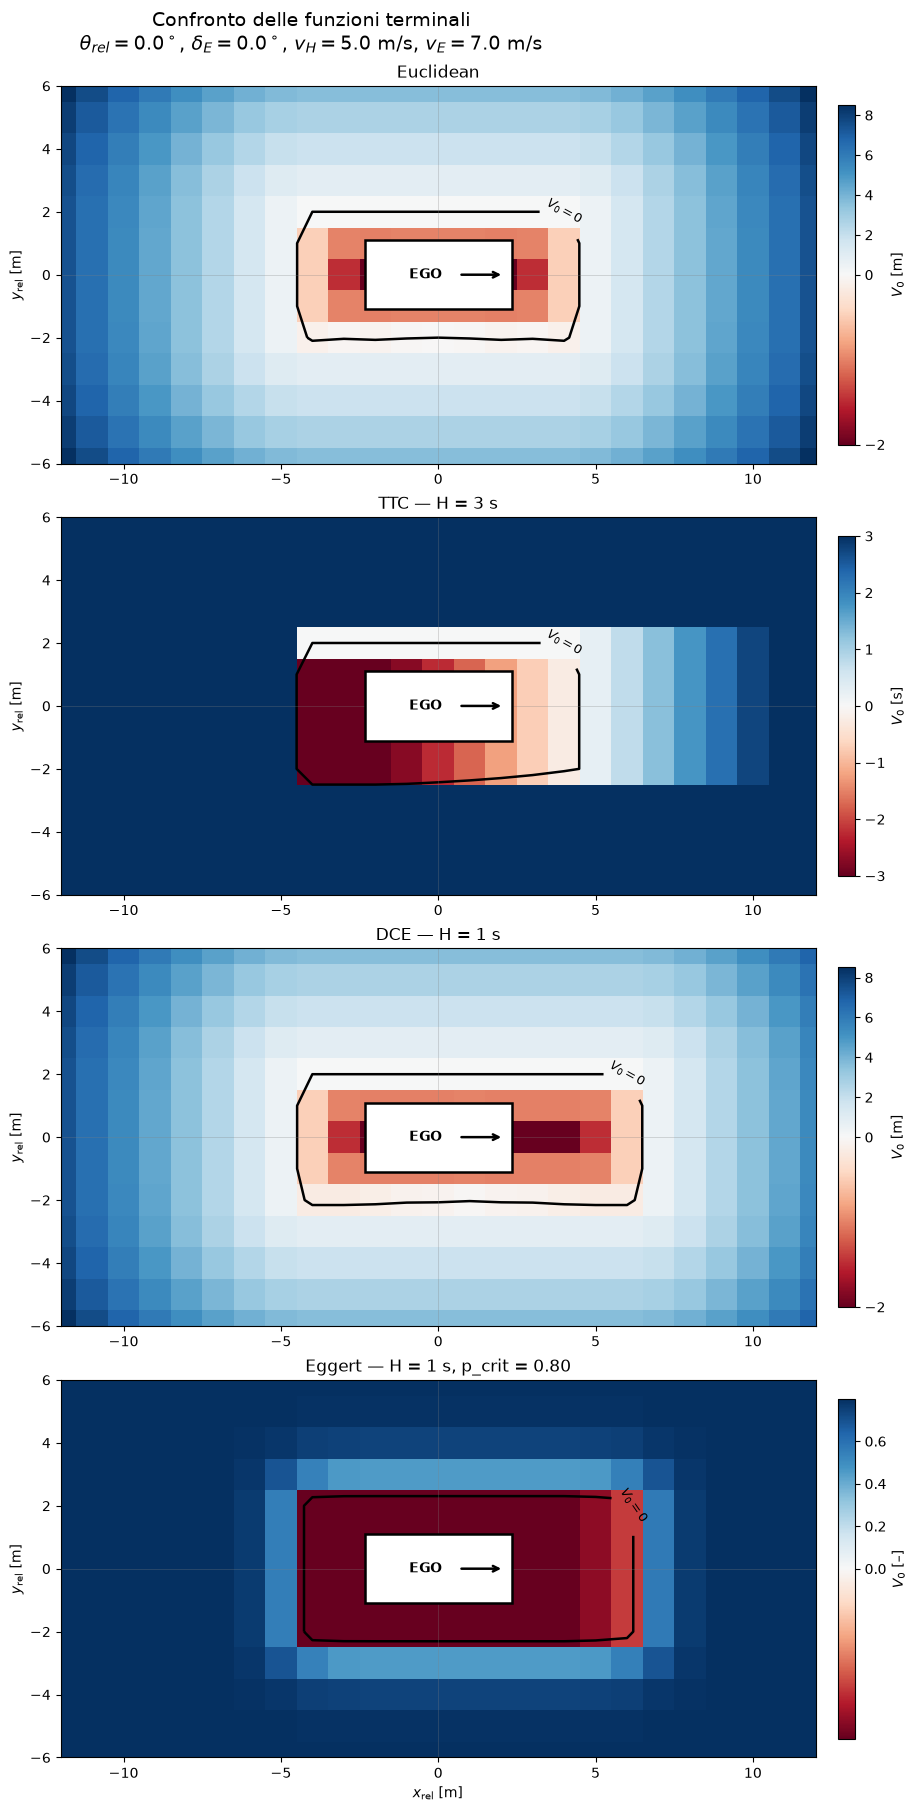

In [14]:
from time import perf_counter

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from matplotlib.patches import Rectangle

from hj_reachability.vehicle.geometry import build_terminal_set_boundary
from hj_reachability.vehicle.metrics import (
    metricEuclidean,
    metricTTC,
    metricDCE,
)

# ============================================================
# 1. PARAMETRI
#    Griglia e dinamica sono quelle della cella precedente.
# ============================================================

TTC_HORIZON = 3.0
TTC_DT = 0.01

DCE_HORIZON = 1.0
DCE_DT = 0.05

N_THETA_BOUNDARY = 90
N_PHI_BOUNDARY = 180

# Riutilizza il risultato Eggert della cella precedente.
eggert_result = result

if eggert_result.terminal_values.shape != tuple(grid.shape):
    raise ValueError("Il risultato Eggert non corrisponde alla griglia.")

# ============================================================
# 2. CALCOLO DELLE ALTRE METRICHE
# ============================================================

boundary = build_terminal_set_boundary(
    n_theta=N_THETA_BOUNDARY,
    n_phi=N_PHI_BOUNDARY,
)

start = perf_counter()
euclidean_result = metricEuclidean(
    grid=grid,
    boundary=boundary,
)
print(f"Euclidean: {perf_counter() - start:.2f} s")

start = perf_counter()
ttc_result = metricTTC(
    grid=grid,
    dynamics=dynamics,
    horizon=TTC_HORIZON,
    dt=TTC_DT,
    collision_tolerance=1e-10,
    batch_size=10_000,
    max_bisection_iterations=60,
)
print(f"TTC: {perf_counter() - start:.2f} s")

start = perf_counter()
dce_result = metricDCE(
    grid=grid,
    dynamics=dynamics,
    boundary=boundary,
    horizon=DCE_HORIZON,
    dt=DCE_DT,
    collision_tolerance=1e-10,
    batch_size=10_000,
)
print(f"DCE: {perf_counter() - start:.2f} s")

# ============================================================
# 3. STESSA FETTA DELLA CELLA PRECEDENTE
# ============================================================

axes = tuple(np.asarray(axis) for axis in grid.coordinate_vectors)
x_axis, y_axis, theta_axis, vh_axis, delta_axis, ve_axis = axes

# Riutilizza gli indici selezionati nella cella precedente.
slice_indices = (
    slice(None),
    slice(None),
    i_theta,
    i_vh,
    i_delta,
    i_ve,
)

X, Y = np.meshgrid(x_axis, y_axis, indexing="ij")

panels = [
    (
        "Euclidean",
        euclidean_result.terminal_values,
        r"$V_0$ [m]",
    ),
    (
        f"TTC — H = {TTC_HORIZON:g} s",
        ttc_result.terminal_values,
        r"$V_0$ [s]",
    ),
    (
        f"DCE — H = {DCE_HORIZON:g} s",
        dce_result.terminal_values,
        r"$V_0$ [m]",
    ),
    (
        (
            f"Eggert — H = {eggert_result.parameters['horizon']:g} s, "
            f"p_crit = {eggert_result.parameters['p_crit']:.2f}"
        ),
        eggert_result.terminal_values,
        r"$V_0$ [–]",
    ),
]

# ============================================================
# 4. FIGURA 4 × 1
# ============================================================

fig, axs = plt.subplots(
    4,
    1,
    figsize=(12, 18),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)

ego = DEFAULT_EGO_GEOMETRY

for ax, (name, values, colorbar_label) in zip(axs, panels):
    field_xy = np.asarray(values)[slice_indices]

    if not np.all(np.isfinite(field_xy)):
        raise ValueError(f"{name}: la fetta contiene valori non finiti.")

    # Scala locale per ogni metrica, con il bianco sempre a zero.
    field_min = float(field_xy.min())
    field_max = float(field_xy.max())
    epsilon = max(abs(field_min), abs(field_max), 1.0) * 1e-6

    norm = TwoSlopeNorm(
        vmin=min(field_min, -epsilon),
        vcenter=0.0,
        vmax=max(field_max, epsilon),
    )

    mesh = ax.pcolormesh(
        X,
        Y,
        field_xy,
        shading="nearest",
        cmap="RdBu",
        norm=norm,
        rasterized=True,
    )

    colorbar = fig.colorbar(mesh, ax=ax, pad=0.02, shrink=0.9)
    colorbar.set_label(colorbar_label)

    if field_min < 0.0 < field_max:
        contour = ax.contour(
            X,
            Y,
            field_xy,
            levels=[0.0],
            colors="black",
            linewidths=1.8,
        )
        ax.clabel(contour, fmt={0.0: r"$V_0=0$"}, fontsize=9)
    else:
        ax.text(
            0.98, 0.95,
            "Nessun cambio di segno nella fetta",
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=9,
            bbox={"facecolor": "white", "alpha": 0.8, "edgecolor": "none"},
        )

    # Ego nell'origine, orientato lungo +x.
    ax.add_patch(Rectangle(
        (-ego.half_length, -ego.half_width),
        ego.length,
        ego.width,
        facecolor="white",
        edgecolor="black",
        linewidth=1.8,
        zorder=5,
    ))

    ax.text(
        -0.4, 0.0, "EGO",
        ha="center",
        va="center",
        weight="bold",
        fontsize=10,
        zorder=6,
    )

    ax.annotate(
        "",
        xy=(ego.half_length - 0.25, 0.0),
        xytext=(0.65, 0.0),
        arrowprops={"arrowstyle": "->", "color": "black", "lw": 1.8},
        zorder=6,
    )

    ax.axhline(0, color="gray", linewidth=0.5, alpha=0.4)
    ax.axvline(0, color="gray", linewidth=0.5, alpha=0.4)

    ax.set_title(name, fontsize=12)
    ax.set_ylabel(r"$y_{\mathrm{rel}}$ [m]")
    ax.set_xlim(x_axis[0], x_axis[-1])
    ax.set_ylim(y_axis[0], y_axis[-1])
    ax.set_aspect("equal", adjustable="box")
    ax.tick_params(axis="x", labelbottom=True)

axs[-1].set_xlabel(r"$x_{\mathrm{rel}}$ [m]")

fig.suptitle(
    "Confronto delle funzioni terminali"
    "\n"
    rf"$\theta_{{rel}}={np.rad2deg(theta_axis[i_theta]):.1f}^\circ$, "
    rf"$\delta_E={np.rad2deg(delta_axis[i_delta]):.1f}^\circ$, "
    rf"$v_H={vh_axis[i_vh]:.1f}$ m/s, "
    rf"$v_E={ve_axis[i_ve]:.1f}$ m/s",
    fontsize=14,
)

plt.show()